<a href="https://colab.research.google.com/github/Lourdes-Churacutipa/Repositorio-de-lourdes/blob/main/Lab6_1_remote_sensing_gee_Peru_share.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Teledetección con Google Earth Engine
## Ciencia de Datos Ambientales – Aplicado al Perú

**Duración:** 75 minutos

**Objetivos de aprendizaje:**
- Comprender los principios físicos de la teledetección
- Configurar Google Earth Engine para uso académico
- Dominar los tipos de datos y operaciones básicas de GEE
- Trabajar con datos ráster (Image) y vectoriales (Feature)
- Aplicar reductores para estadísticas espaciales y temporales
- Calcular e interpretar índices de vegetación (NDVI) en el Perú

---

## 1. Introducción a la Teledetección

### 1.1 ¿Qué es la teledetección?

La **teledetección** es la ciencia de adquirir información sobre objetos o áreas a distancia, típicamente desde aeronaves o satélites. A diferencia de las mediciones de campo donde se visita físicamente un lugar, la teledetección permite observar todo el planeta de forma repetida.

**¿Por qué es importante para la ciencia ambiental peruana?**
1. **Escala:** Podemos observar toda la Amazonia o los Andes, no solo parcelas de estudio
2. **Consistencia:** Los satélites recopilan datos con los mismos sensores en todas partes
3. **Cobertura temporal:** Muchos satélites llevan décadas recopilando datos
4. **Acceso:** Podemos estudiar zonas remotas (cabeceras de cuencas, glaciares, bosques inaccesibles)
5. **Costo:** Una vez lanzados los satélites, la recopilación de datos es relativamente económica

### 1.2 El espectro electromagnético

Toda teledetección se basa en medir la **radiación electromagnética**. La clave es que diferentes materiales en la superficie terrestre interactúan de manera diferente con diferentes longitudes de onda.

**¿Cómo funciona?**
1. El **Sol** emite radiación electromagnética en muchas longitudes de onda
2. Esta radiación llega a la Tierra y toca la superficie
3. Diferentes superficies **absorben**, **reflejan** o **transmiten** diferentes longitudes de onda
4. Los satélites miden la radiación **reflejada**

Piénsalo así: una manzana roja se ve roja porque absorbe la luz azul y verde, pero refleja la luz roja hacia nuestros ojos. Los satélites hacen lo mismo, pero pueden "ver" longitudes de onda que van más allá de lo que el ojo humano puede detectar.

### 1.3 Bandas espectrales y sus aplicaciones

| Banda | Longitud de onda | Qué mide | Aplicación en Perú |
|-------|------------------|----------|-------------------|
| **Azul** | 0.45-0.52 µm | Luz dispersada | Turbidez del agua en ríos amazónicos |
| **Verde** | 0.52-0.60 µm | Reflectancia de vegetación | Vigor de cultivos en costa |
| **Rojo** | 0.63-0.69 µm | Absorción de clorofila | Salud de vegetación, deforestación |
| **NIR** | 0.76-0.90 µm | Estructura celular foliar | Biomasa amazónica, cobertura forestal |
| **SWIR** | 1.55-2.35 µm | Agua en hojas/suelo | Estrés hídrico, geología andina |
| **Térmico** | 10.4-12.5 µm | Calor emitido | Temperatura de lagos (Titicaca), glaciares |

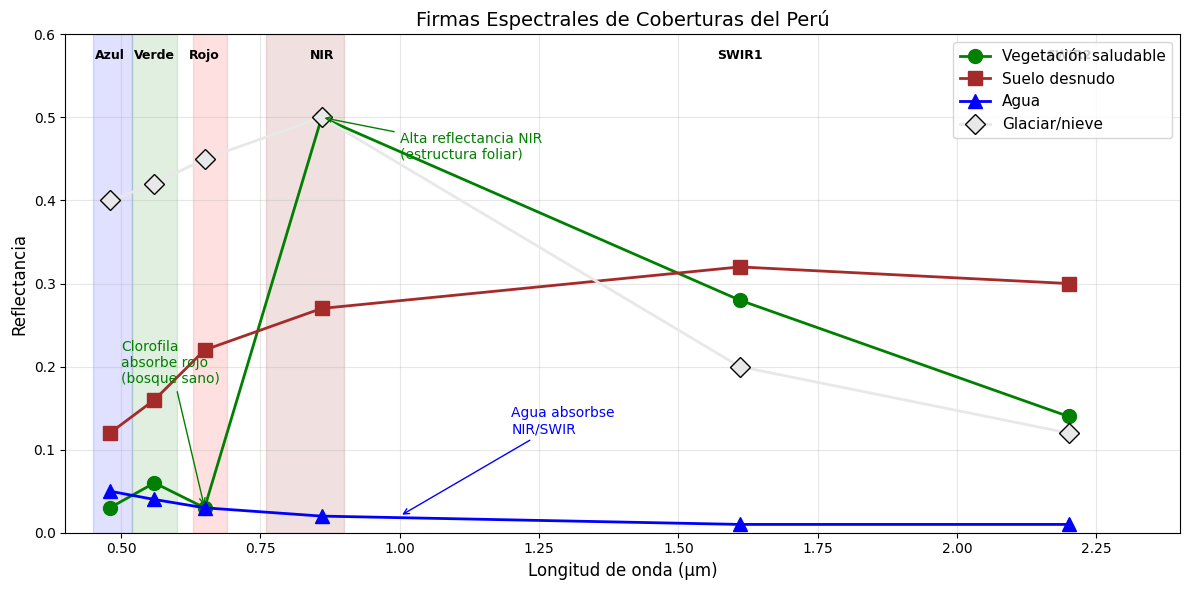

In [ ]:
# Visualizar firmas espectrales típicas de coberturas peruanas
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Longitudes de onda de las bandas de Landsat (en micrómetros)
longitudes_onda = [0.48, 0.56, 0.65, 0.86, 1.61, 2.20]
nombres_bandas  = ['Azul', 'Verde', 'Rojo', 'NIR', 'SWIR1', 'SWIR2']

# Valores típicos de reflectancia (proporción de luz reflejada, 0–1)
bosque_amazonico = [0.03, 0.06, 0.03, 0.50, 0.28, 0.14]  # NIR alto, Rojo bajo
suelo_andino     = [0.12, 0.16, 0.22, 0.27, 0.32, 0.30]  # gradualmente creciente
lago_titicaca    = [0.05, 0.04, 0.03, 0.02, 0.01, 0.01]  # muy bajo en NIR
glacier_nevado   = [0.40, 0.42, 0.45, 0.50, 0.20, 0.12]  # alto en visible

ax.plot(longitudes_onda, bosque_amazonico, 'g-o',    lw=2, ms=10, label='Vegetación saludable')
ax.plot(longitudes_onda, suelo_andino, ls='-', marker='s',     lw=2, ms=10, color='brown', label='Suelo desnudo')
ax.plot(longitudes_onda, lago_titicaca,    'b-^',    lw=2, ms=10, label='Agua')
ax.plot(longitudes_onda, glacier_nevado, 'D', color="#E9E8E8", ls='-', mec='k', lw=2, ms=10, label='Glaciar/nieve')

# Sombrear regiones espectrales
ax.axvspan(0.45, 0.52, alpha=0.12, color='blue')
ax.axvspan(0.52, 0.60, alpha=0.12, color='green')
ax.axvspan(0.63, 0.69, alpha=0.12, color='red')
ax.axvspan(0.76, 0.90, alpha=0.12, color='darkred')

# Anotaciones para explicar características clave
ax.annotate('Clorofila\nabsorbe rojo\n(bosque sano)', xy=(0.65, 0.03), xytext=(0.50, 0.18),
            arrowprops=dict(arrowstyle='->', color='green'), fontsize=10, color='green')
ax.annotate('Alta reflectancia NIR\n(estructura foliar)', xy=(0.86, 0.50), xytext=(1.0, 0.45),
            arrowprops=dict(arrowstyle='->', color='green'), fontsize=10, color='green')

ax.annotate('Agua absorbse\nNIR/SWIR', xy=(1.0, 0.02), xytext=(1.2, 0.12),
            arrowprops=dict(arrowstyle='->', color='blue'), fontsize=10, color='blue')

ax.set_xlabel('Longitud de onda (µm)', fontsize=12)
ax.set_ylabel('Reflectancia', fontsize=12)
ax.set_title('Firmas Espectrales de Coberturas del Perú', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.4, 2.4)
ax.set_ylim(0, 0.6)

# Añadir etiquetas de bandas
for wl, name in zip(longitudes_onda, nombres_bandas):
    ax.annotate(name, (wl, 0.57), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### 1.4 Comprensión de la firma espectral de la vegetación

El gráfico anterior revela por qué la teledetección satelital es tan eficaz para el monitoreo de la vegetación:

**¿Por qué la vegetación tiene una baja reflectancia en rojo?**
- Las moléculas de clorofila absorben la luz roja (y la azul) para impulsar la fotosíntesis.
- Las plantas sanas con abundante clorofila absorben más luz roja.
- Las plantas estresadas o moribundas tienen menos clorofila, por lo que reflejan más luz roja (apareciendo amarillentas).

**¿Por qué la vegetación tiene una alta reflectancia en el infrarrojo cercano (NIR)?**
- La estructura interna de las hojas (células del mesófilo esponjoso) dispersa fuertemente la luz NIR.
- Esto no tiene nada que ver con la clorofila; es puramente una característica de la estructura física.
- Más capas de hojas = mayor reflexión NIR = mayor biomasa.

**¿Por qué el agua absorbe el NIR?**
- Las moléculas de agua absorben fuertemente la radiación infrarroja.
- Por eso el agua aparece muy oscura en las imágenes NIR.
- Esta propiedad nos permite distinguir fácilmente el agua de la tierra.

### 1.5 Satélites principales para el monitoreo ambiental del Perú

Los distintos satélites están diseñados para diferentes propósitos. Las principales ventajas y desventajas son:

- **Resolución espacial**: ¿Qué tan pequeño es un objeto que puede observar?
- **Resolución temporal**: ¿Con qué frecuencia el satélite vuelve a visitar la misma ubicación?
- **Resolución espectral**: ¿Cuántas bandas utiliza y qué tan estrechas son?

| Satélite | Resolución espacial | Revisita | Archivo desde | Mejor para en Perú |
|----------|--------------------|-----------|--------------|-----------------|
| **Landsat 8/9** | 30 m | 16 días (8 con ambos) | 1972 | Deforestación, cambio de cobertura a largo plazo |
| **Sentinel-2** | 10-20 m | 5 días | 2015 | Agricultura en costa, detalle de vegetación |
| **MODIS** | 250-1000 m | Diario | 2000 | Fenología, incendios amazónicos, patrones globales |
| **GOES-19** | 500 m-2 km | 5-15 min | 2017 | Monitoreo de nubes, eventos extremos |


**La disyuntiva de la resolución**: Generalmente, no se puede tener alta resolución espacial Y alta resolución temporal simultáneamente. Un satélite capaz de captar detalles de 1 metro tarda más en cubrir toda la Tierra que uno con píxeles de 500 metros.

Para este curso, utilizaremos principalmente **Landsat 8** (buen equilibrio entre resolución e historial) y **MODIS** (excelente para series temporales y fenología).


> **Nota sobre nubes en Perú:** La Amazonia peruana tiene alta cobertura de nubes (>70% del año). Landsat y Sentinel-2 tienen revisitas largas y pueden tener pocas imágenes libres de nubes. MODIS con revisita diaria y los compuestos mensuales son a menudo más prácticos para la región amazónica.



---
## 2. Introducción a Google Earth Engine

### 2.1 ¿Qué es Google Earth Engine?

**Google Earth Engine (GEE)** es una plataforma basada en la nube que combina:
1. **Un catálogo masivo de datos**: Petabytes de imágenes satelitales, datos climáticos y de terreno, todos preprocesados y listos para usar
2. **Infraestructura de computación en la nube**: En lugar de descargar archivos enormes a tu laptop, escribes código que se ejecuta en los servidores de Google
3. **Acceso gratuito para investigación y educación**

**¿Por qué usar GEE en lugar de descargar datos?**

| Enfoque tradicional | Google Earth Engine |
|---------------------|---------------------|
| Búsqueda de datos en el sitio web del USGS | Datos ya organizados e indexados |
| Descarga de GB/TB de archivos | Los datos permanecen en los servidores de Google |
| Almacenamiento en tu disco duro | No se necesita almacenamiento local |
| Procesamiento en tu portátil (lento) | Procesamiento en la nube de Google (rápido) |
| Instalación de software complejo | Solo necesitas un navegador web o Python |

### 2.2 Cómo registrarse en Google Earth Engine

Antes de poder usar GEE, debe registrarse para obtener acceso y crear un proyecto en la nube. Siga estos pasos cuidadosamente:

### **Nota importante:**
En ocasiones, los pasos pueden variar con respecto a lo que se describe a continuación. Es posible que deba explorar la página web hasta obtener un ID de proyecto.

---

#### Paso 1: Ir a la página de registro

Abre tu navegador web y navega a:

**https://code.earthengine.google.com/register**

---

#### Paso 2: Inicia sesión con tu cuenta de Google

- Usa el mismo correo electrónico que usaste para **colab**
- Haz clic en "Iniciar sesión" e ingresa tus credenciales

---

#### Paso 3: Registrarse como usuario académico

En la página de registro:

1. **Seleccione su tipo de cuenta**: Elija **"Uso gratuito"** → **"Academia e Investigación"**

2. **Complete el formulario de registro**:

- **Institución**: SENAMHI / Universidad (según corresponda)

- **Tipo de institución**: Universidad

- **¿Cómo utilizará Earth Engine?**: Seleccione "Educación/Investigación"

- **Describa su proyecto**: Escriba una breve descripción, por ejemplo:

> "Curso de pregrado en ciencia de datos ambientales. Uso de imágenes satelitales para analizar la cobertura terrestre, la fenología de la vegetación y el cambio ambiental para trabajos de clase." o en ingles "Undergraduate coursework in environmental data science. Using satellite imagery to analyze land cover, vegetation phenology, and environmental change for class assignments."

3. **Acepte los Términos de Servicio**: Léalos y marque la casilla.

4. **Haga clic en "Registrarse"**

---
#### Paso 4: Crear un proyecto de Google Cloud

Después de registrarte, debes crear un **Proyecto de Cloud**. Así es como Google organiza y realiza el seguimiento del uso.

1. Ve a: **https://console.cloud.google.com/**

2. Si se te solicita, acepta los Términos del Servicio.

3. Haz clic en el menú desplegable de proyectos en la parte superior de la página (puede que diga "Seleccionar un proyecto").

4. Haz clic en **"Nuevo proyecto"** en la esquina superior derecha de la ventana emergente.

5. **Configura tu proyecto**:

- **Nombre del proyecto**: Elige un nombre fácil de recordar, por ejemplo, `ee-fw-ecol-458` o `ee-tunombre-clase`.

- **Organización**: Deja "Sin organización" (o selecciona tu universidad si está disponible).

- **Ubicación**: Deja la ubicación predeterminada.

6. Haz clic en **"Crear"**.

7. **Guarda tu ID de proyecto**: Después de crearlo, anota tu **ID de proyecto** (que se muestra en el panel de control del proyecto). Tiene el formato `ee-fw-ecol-458` o podría tener números añadidos, como `ee-fw-ecol-458-12345`. **Necesitarás este ID en tu código.**

---
#### Paso 5: Habilitar la API de Earth Engine

1. En la consola de Google Cloud, asegúrese de que su nuevo proyecto esté seleccionado.

2. Vaya a: **https://console.cloud.google.com/apis/library/earthengine.googleapis.com**

3. Haga clic en **"Habilitar"** para habilitar la API de Earth Engine para su proyecto.

---

#### Paso 6: Verificar la configuración

1. Vaya al editor de código de Earth Engine: **https://code.earthengine.google.com/**

2. Si ve la interfaz del editor de código con un mapa, ¡ya está listo!

3. Si recibe un error, espere de 5 a 10 minutos para que se propague el registro y vuelva a intentarlo.

---

#### Solución de problemas comunes

| Problema | Solución |
|---------|----------|
| Error "Acceso denegado" | Espere de 10 a 15 minutos; El registro puede tardar en procesarse |
| No se encuentra el ID del proyecto | Ve a console.cloud.google.com y haz clic en el menú desplegable del proyecto |
| Error "API no habilitada" | Asegúrate de haber completado el paso 5 |
| "Cuota excedida" | Es poco probable que se utilice en clase; contacta con el profesor si esto ocurre |

---

### 2.3 Configuración del acceso a Earth Engine mediante Python

Si bien GEE cuenta con un editor de código JavaScript (code.earthengine.google.com), utilizaremos la **API de Python** para poder integrarnos con pandas, matplotlib y otras herramientas que ya conoces.

In [ ]:
# Instalar paquetes requeridos (ejecutar una sola vez)
!pip install geemap earthengine-api -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 47.6 MB/s eta 0:00:00


In [ ]:
# Importar la biblioteca Earth Engine
import ee

# Importar geemap para mapas interactivos
import geemap

# Otras bibliotecas que usaremos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# AUTENTICACIÓN (Ejecute esta celda y siga las instrucciones)
# # Esto abrirá una ventana del navegador donde deberá iniciar sesión en Google
# y otorgar permiso para que este cuaderno acceda a Earth Engine.

# # Solo necesita hacer esto una vez por sesión.

ee.Authenticate()

True

In [ ]:
# INICIALIZACIÓN
# # Reemplaza 'tu-id-de-proyecto' con el ID del proyecto que creaste en el paso 4.

# Por ejemplo: 'ee-fw-ecol-458' o 'ee-jsmith-class'
#
# IMPORTANTE: ¡Debe coincidir exactamente con lo que se muestra en tu consola de Google Cloud!

ee.Initialize(project='ee-cmillanarancibia') # <-- Tengo un ID de proyecto 'utec-ingcivil-01' en mi cuenta de UTEC. DEBES REEMPLAZARLO con el tuyo.

# Comprueba que funcionó
print("¡Earth Engine se inicializó correctamente!")
print(f"Versión de Earth Engine: {ee.__version__}")

¡Earth Engine se inicializó correctamente!
Versión de Earth Engine: 1.7.28


---
## 3. Tipos de datos en GEE

### 3.1 Servidor vs. Cliente

El concepto más importante que hay que entender sobre GEE es la distinción entre objetos del **lado del servidor** y del **lado del cliente**:

| Del lado del cliente (tu computadora) | Del lado del servidor (nube de Google) |
|---------------------------------------|-----------------------------------------|
| Variables Python regulares | Objetos `ee.` |
| `x = 5` | `x = ee.Number(5)` |
| Se calculan inmediatamente | Se calculan solo cuando se solicitan |

**Información clave**: Cuando escribes `ee.Image(...)` o `ee.Filter.lt(...)`, no realizas el cálculo, sino que creas una **receta** que le indica a Google qué calcular. El cálculo real se realiza en los servidores de Google solo cuando llamas a `.getInfo()` o visualizas los datos.

Esto se conoce como **evaluación diferida** y es lo que hace que GEE sea tan potente - Google puede optimizar el cálculo y procesar únicamente los datos que realmente necesitas.

### 3.2 Tipos de datos principales

GEE tiene varios tipos de datos fundamentales:

| Tipo | Descripción | Ejemplo en Perú |
|------|-------------|---------------|
| `ee.Image` | Una imagen ráster con bandas | Una escena Landsat sobre Lima |
| `ee.ImageCollection` | Serie temporal de imágenes | Todas las escenas Landsat del 2023 |
| `ee.Geometry` | Una forma vectorial | Punto en Lima o polígono del departamento de Madre de Dios |
| `ee.Feature` | Una geometría con propiedades | Un departamento con su nombre y área |
| `ee.FeatureCollection` | Colección de features | Todos los departamentos del Perú |
| `ee.Number` | Un número (en el servidor) | Una estadística calculada |
| `ee.String` | Una cadena (en el servidor) | Un nombre de banda |
| `ee.List` | Una lista (en el servidor) | Lista de nombres de bandas |
| `ee.Dictionary` | Un diccionario (en el servidor) | Metadatos de la imagen |

Exploremos cada una de estas con ejemplos.

### 3.3 Trabajando con ee.Geometry

Las geometrías definen **dónde** en la Tierra se desea analizar. Son la base para filtrar datos y extraer estadísticas.

In [ ]:
# Crear geometrías de lugares del Perú

# PUNTOS de ciudades peruanas (longitud, latitud)
# Nota: GEE utiliza el orden (longitud, latitud), no (latitud, longitud).
lima        = ee.Geometry.Point([-77.0428, -12.0464])
cusco       = ee.Geometry.Point([-71.9675, -13.5319])
iquitos     = ee.Geometry.Point([-73.2516, -3.7437])
arequipa    = ee.Geometry.Point([-71.5350, -16.4090])
pucallpa    = ee.Geometry.Point([-74.5539, -8.3791])

# RECTÁNGULO: Un cuadro delimitador definido por [oeste, sur, este, norte]
lima_reg = ee.Geometry.Rectangle([-78.5, -13.5, -75.7, -10.8])

# POLÍGONO: Una forma personalizada definida por una lista de coordenadas
# El primer y el último punto deben ser iguales para cerrar el polígono
custom_area = ee.Geometry.Polygon([
    [[-89.5, 43.0],
     [-89.3, 43.0],
     [-89.3, 43.2],
     [-89.5, 43.2],
     [-89.5, 43.0]] # Cerrar el polígono
])

# BUFFER: zona de 50 km alrededor de Lima
lima_50km = lima.buffer(50000)

print("Geometrías de lugares del Perú creadas exitosamente!")

Geometrías de lugares del Perú creadas exitosamente!


In [ ]:
# Visualizar en mapa interactivo
Mapa = geemap.Map(center=[-9.19, -75.01], zoom=6)
Mapa.addLayer(lima_reg, {'color': 'blue'}, 'Lima Rectangle')
Mapa.addLayer(lima_50km, {'color': 'red'}, 'Lima 50km buffer')
Mapa.addLayer(lima, {'color': 'yellow'}, 'Lima')
Mapa.addLayer(cusco, {'color': 'orange'}, 'Cusco')
Mapa.addLayer(iquitos, {'color': 'cyan'}, 'Iquitos')
Mapa

Map(center=[-9.19, -75.01], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [ ]:
# Operaciones geometricas

# Calcular el area en metros cuadrados
area_lima = lima_reg.area().getInfo()
area_lima_km2 = area_lima / 1e6
print(f"Area de la region Lima: {area_lima_km2:,.0f} km2")

# Distancia Lima - Cusco
dist_lima_cusco = lima.distance(cusco).getInfo()
print(f"Distancia Lima a Cusco: {dist_lima_cusco/1000:.0f} km")

# Encontrar el centroide de la region
centroide = lima_reg.centroid()
coords = centroide.coordinates().getInfo()
print(f"Centroide: {coords[1]:.4f}S, {abs(coords[0]):.4f}O")

# Verificar si una geometria contiene a otra
lima_en_region = lima_reg.contains(lima).getInfo()
print(f"Esta Lima dentro de la region Lima? {lima_en_region}")

Area de la region Lima: 91,388 km2
Distancia Lima a Cusco: 575 km
Centroide: -12.1512S, 77.1000O
Esta Lima dentro de la region Lima? True


---
### 3.4 Trabajando con ee.Feature y ee.FeatureCollection

Un **Feature** es una geometría con propiedades asociadas (similar a los atributos de un shapefile).
Una **FeatureCollection** es un grupo de features — equivalente a una capa vectorial en un SIG.

GEE incluye muchas FeatureCollections ya cargadas en su catálogo:
límites administrativos, áreas protegidas, cuencas hidrográficas, y mucho más.

In [ ]:
# Crear un Feature manualmente (geometría + propiedades)
lima_feature = ee.Feature(lima, {
    'nombre': 'Lima',
    'poblacion': 10628000,
    'es_capital': True,
    'departamento': 'Lima'
})

# Acceder a propiedades del Feature
nombre = lima_feature.get('nombre').getInfo()
pob    = lima_feature.get('poblacion').getInfo()
print(f"{nombre}: {pob:,} habitantes")

Lima: 10,628,000 habitantes


In [ ]:
# Cargar una FeatureCollection del catálogo GEE
# FAO GAUL (Global Administrative Unit Layers) — límites administrativos mundiales
departamentos_peru = (
    ee.FeatureCollection('FAO/GAUL/2015/level1')
    .filter(ee.Filter.eq('ADM0_NAME', 'Peru'))
)

total_deptos = departamentos_peru.size().getInfo()
print(f"Departamentos del Perú en GEE: {total_deptos}")

# Obtener un departamento específico — Madre de Dios
mdd_depto = departamentos_peru.filter(
    ee.Filter.eq('ADM1_NAME', 'Madre de Dios')
).first()

# Obtener un departamento específico — Lima
lima_depto = departamentos_peru.filter(
    ee.Filter.eq('ADM1_NAME', 'Lima')
).first()

props = lima_depto.getInfo()['properties']
print(f"\nPropiedades:")
print(f"  Nombre: {props['ADM1_NAME']}")
print(f"  País:   {props['ADM0_NAME']}")
print(f"  Código: {props['ADM1_CODE']}")

Departamentos del Perú en GEE: 25

Propiedades:
  Nombre: Lima
  País:   Peru
  Código: 2342


In [ ]:
# Más operaciones de filtrado

# Filtrar por lista de valores
deptos_sur = departamentos_peru.filter(
    ee.Filter.inList('ADM1_NAME', ['Puno', 'Arequipa', 'Cusco', 'Madre de Dios', 'Apurimac'])
)
print(f"Departamentos del sur seleccionados: {deptos_sur.size().getInfo()}")

# Filtrar por intersección espacial
deptos_amazonia = departamentos_peru.filterBounds(
    ee.Geometry.Rectangle([-73.5, -12.5, -68.7, -3.0])
)
print(f"Departamentos en la Amazonia: {deptos_amazonia.size().getInfo()}")

# Listar sus nombres
nombres = deptos_amazonia.aggregate_array('ADM1_NAME').getInfo()
print(f"Nombres: {sorted(nombres)}")

Departamentos del sur seleccionados: 4
Departamentos en la Amazonia: 5
Nombres: ['Cusco', 'Junín', 'Loreto', 'Madre de Dios', 'Ucayali']


In [ ]:
# Visualizar departamentos del Perú
Mapa_deptos = geemap.Map(center=[-9.19, -75.01], zoom=5)

# Todos los departamentos (solo borde, sin relleno)
Mapa_deptos.addLayer(
    departamentos_peru,
    {'color': 'blue', 'fillColor': '00000000'},
    'Departamentos del Perú'
)

# Resaltar Madre de Dios en rojo
Mapa_deptos.addLayer(
    mdd_depto,
    {'color': 'red', 'fillColor': 'FF000044'},
    'Madre de Dios'
)

Mapa_deptos

Map(center=[-9.19, -75.01], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

---
## 4. Trabajar con ee.Image: Imágenes Satelitales


### 4.1 ¿Qué es un ee.Image?

Un `ee.Image` es un **ráster** — una cuadrícula de píxeles donde cada píxel tiene uno o más valores (bandas). A diferencia de una fotografía (que tiene 3 bandas: Rojo, Verde, Azul), las imágenes satelitales suelen tener muchas más bandas que cubren distintas partes del espectro electromagnético.

**Conceptos clave:**
- **Bandas**: Diferentes "capas" de datos (ej. azul, verde, rojo, NIR)
- **Píxeles**: Las celdas individuales de la cuadrícula
- **Resolución**: El tamaño de cada píxel sobre el terreno (ej. 30 metros en Landsat)
- **Proyección**: Cómo se mapea la Tierra curva a una imagen plana

Podemos acceder a las propiedades de cualquier imagen con `.bandNames()`, `.projection()`, y la información del tipo de dato de cada banda.

In [ ]:
# Cargar una sola imagen del catálogo
# Este es el Modelo Digital de Elevación SRTM: datos de elevación global
dem = ee.Image('USGS/SRTMGL1_003')

print("Propiedades del DEM SRTM:")
print(f"  Nombres de bandas: {dem.bandNames().getInfo()}")
print(f"  Proyección (SRC):  {dem.projection().getInfo()['crs']}")

# Información detallada de la banda de elevación
info_banda = dem.select('elevation').getInfo()
print(f"  Tipo de dato: {info_banda['bands'][0]['data_type']}")
print()
print("Nota: Un ee.Image puede tener una o muchas bandas.")
print("      Cada banda puede tener un tipo de dato distinto (entero, flotante, etc.)")

Propiedades del DEM SRTM:
  Nombres de bandas: ['elevation']
  Proyección (SRC):  EPSG:4326
  Tipo de dato: {'type': 'PixelType', 'precision': 'int', 'min': -32768, 'max': 32767}

Nota: Un ee.Image puede tener una o muchas bandas.
      Cada banda puede tener un tipo de dato distinto (entero, flotante, etc.)


In [ ]:
# Cargar el Modelo de Elevación SRTM (global)
dem = ee.Image('USGS/SRTMGL1_003')

print(f"Bandas del DEM: {dem.bandNames().getInfo()}")

# Visualizar elevación del Perú
peru_bbox = ee.Geometry.Rectangle([-81.5, -18.5, -68.5, 0.5])

Mapa2 = geemap.Map(center=[-9.19, -75.01], zoom=5)

vis_elevacion = {
    'min': 0,
    'max': 5000,
    'palette': ['#006633', '#E5FFCC', '#FFD700', '#996633', '#FFFFFF']
    # verde bajo → amarillo → marrón → blanco (nieves)
}

Mapa2.addLayer(dem.clip(peru_bbox), vis_elevacion, 'Elevación Perú (SRTM)')
Mapa2.add_colorbar(vis_elevacion, label='Elevación (m)')
Mapa2

Bandas del DEM: ['elevation']


Map(center=[-9.19, -75.01], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

### 4.2 Imágenes Landsat sobre el Perú

La mayoría de los datos satelitales se presentan como una **colección de imágenes**, una serie temporal de imágenes. Aprenderemos a filtrar colecciones, pero primero veamos cómo obtener una sola imagen.

In [ ]:
# Cargar colección Landsat 8 y filtrar sobre Madre de Dios
landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')

imagen = (landsat
    .filterDate('2026-02-15', '2026-12-31')   # época seca (julio-agosto)
    .filterBounds(lima)
    .filter(ee.Filter.lt('CLOUD_COVER', 30))   # < 20% nubes
    .sort('CLOUD_COVER')
    .first()
)

print(f"Bandas disponibles: {imagen.bandNames().getInfo()[:8]}")

# What bands does it have?
print("Landsat 8 bands:")
for band in imagen.bandNames().getInfo():
    print(f"  {band}")

Bandas disponibles: ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL']
Landsat 8 bands:
  SR_B1
  SR_B2
  SR_B3
  SR_B4
  SR_B5
  SR_B6
  SR_B7
  SR_QA_AEROSOL
  ST_B10
  ST_ATRAN
  ST_CDIST
  ST_DRAD
  ST_EMIS
  ST_EMSD
  ST_QA
  ST_TRAD
  ST_URAD
  QA_PIXEL
  QA_RADSAT


#### Referencia de bandas Landsat 8

| Banda | Descripción | Longitud de onda | Resolución |
|-------|-------------|-----------------|------------|
| SR_B2 | Azul | 0.45-0.51 µm | 30 m |
| SR_B3 | Verde | 0.53-0.59 µm | 30 m |
| SR_B4 | Rojo | 0.64-0.67 µm | 30 m |
| SR_B5 | NIR | 0.85-0.88 µm | 30 m |
| SR_B6 | SWIR1 | 1.57-1.65 µm | 30 m |
| SR_B7 | SWIR2 | 2.11-2.29 µm | 30 m |
| ST_B10 | Thermal | 10.6-11.2 µm | 100 m |
| QA_PIXEL | Quality flags | - | 30 m |

In [ ]:
# Los datos de la Colección 2 de Landsat requieren escalado.
# Los valores brutos son enteros; necesitamos convertirlos a reflectancia (0-1).

# Aplicar factores de escala
def escalar_landsat(img):
    """
    Aplicar factores de escala a la reflectancia superficial de la Colección 2 de Landsat.
    La fórmula es: reflectancia = DN * 0,0000275 + (-0,2)
    Esto convierte los números enteros almacenados en valores de reflectancia reales.
    """

    bandas_opt = ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']
    opt = img.select(bandas_opt)

    escalada = opt.multiply(0.0000275).add(-0.2)
    return img.addBands(escalada, overwrite=True)

imagen = escalar_landsat(imagen)
print("Imagen escalada a valores de reflectancia (0–1)")

Imagen escalada a valores de reflectancia (0–1)


In [ ]:
# Visualizar imagen
# Color verdadero: Las bandas roja, verde y azul se muestran como RGB.
color_verdadero = {'bands': ['SR_B4', 'SR_B3', 'SR_B2'], 'min': 0, 'max': 0.3}

# Falso color: NIR, rojo y verde se muestran como RGB
# La vegetación aparece de un rojo brillante porque NIR se muestra como rojo
color_falso     = {'bands': ['SR_B5', 'SR_B4', 'SR_B3'], 'min': 0, 'max': 0.4}

Mapa3 = geemap.Map(center=[-12.0464 , -77.0428 ], zoom=8)
Mapa3.addLayer(imagen, color_verdadero, 'Color verdadero') #.clip(madre_de_dios)
Mapa3.addLayer(imagen, color_falso, 'Color falso (vegetación = rojo)') #.clip(madre_de_dios)
Mapa3

Map(center=[-12.0464, -77.0428], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

---
## 5. Matemáticas de bandas e índices espectrales: NDVI

Una de sus capacidades más potentes consiste en combinar matemáticamente las bandas para crear **índices espectrales** que resaltan características específicas.

### 5.1 NDVI – Índice de Vegetación de Diferencia Normalizada

$$\text{NDVI} = \frac{\text{NIR} - \text{Rojo}}{\text{NIR} + \text{Rojo}}$$

**¿Por qué funciona?**
- Vegetación sana: NIR **alto**, Rojo **bajo** → NDVI cerca de +1
- Suelo desnudo: NIR y Rojo similares → NDVI cerca de 0
- Agua: NIR muy **bajo** → NDVI negativo
- Área deforestada: NDVI cae abruptamente

### 5.2 Otros índices útiles en Perú

| Índice | Fórmula | Uso en Perú |
|--------|---------|-------------|
| **NDWI** | (Verde - NIR)/(Verde + NIR) | Cuerpos de agua (río Amazonas, lagunas altoandinas) |
| **NDMI** | (NIR - SWIR1)/(NIR + SWIR1) | Humedad de vegetación, estrés hídrico |
| **NBR** | (NIR - SWIR2)/(NIR + SWIR2) | Áreas quemadas en la Amazonia |

In [ ]:
# NDVI: Índice de Vegetación de Diferencia Normalizada
# # Fórmula: NDVI = (NIR - Rojo) / (NIR + Rojo)
# # Por qué funciona:
# - Vegetación sana: NIR ALTO, Rojo BAJO → NDVI cercano a +1
# - Suelo desnudo: NIR y Rojo similares → NDVI cercano a 0
# - Agua: NIR BAJO, Rojo ligeramente superior → NDVI negativo
#
# La normalización (dividir por la suma) permite comparar los resultados en
# diferentes condiciones de iluminación y calibraciones de sensores.

# Calcular índices espectrales
ndvi = imagen.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')


# Añadir índices a la imagen
imagen_con_indices = imagen.addBands([ndvi, ndwi, nbr])

# Visualizar NDVI
vis_ndvi = {
    'min': -0.2,
    'max': 0.9,
    'palette': ['#d73027', # Rojo: negativo (agua)
                '#fc8d59', # Naranja: bajo (suelo desnudo)
                '#fee08b', # Amarillo: moderado
                '#d9ef8b', # Verde claro: vegetación
                '#91cf60', # Verde medio: vegetación sana
                '#1a9850', # Verde oscuro: vegetación densa
                ]
}

Mapa4 = geemap.Map(center=[-12.0464 , -77.0428 ], zoom=9)
Mapa4.addLayer(ndvi.clip(lima_reg), vis_ndvi, 'NDVI')
Mapa4.add_colorbar(vis_ndvi, label='NDVI')
Mapa4

Map(center=[-12.0464, -77.0428], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [ ]:

# Otros índices útiles

# NDWI: Índice de Diferencia Normalizada del Agua
# Resalta las masas de agua (valores positivos = agua)
ndwi = imagen.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI')

# NDBI: Índice de Diferencia Normalizada de Áreas Urbanizadas
# Resalta las áreas urbanas/desarrolladas (valores positivos = áreas urbanizadas)
ndbi = imagen.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')

# NDMI: Índice de Diferencia Normalizada de la Humedad
# Sensible al contenido de agua de la vegetación
ndmi = imagen.normalizedDifference(['SR_B5', 'SR_B6']).rename('NDMI')

# NBR: Índice de Areas quemadas
# Sensible a zonas quemadas
nbr  = imagen.normalizedDifference(['SR_B5', 'SR_B7']).rename('NBR')

# Agregar todos los índices a la imagen
imagen_con_índices = imagen.addBands([ndvi, ndwi, ndbi, ndmi, nbr])
print(f"Imagen ahora tiene {imagen_con_índices.bandNames().size().getInfo()} bandas")

Imagen ahora tiene 24 bandas


In [ ]:
# Comparar índices: NDVI, NDWI, NBR
Mapa5 = geemap.Map(center=[-12.0464 , -77.0428 ], zoom=9)

Mapa5.addLayer(ndvi.clip(lima_depto),
               {'min': 0, 'max': 0.9, 'palette': ['brown', 'yellow', 'darkgreen']},
               'NDVI (Vegetación)')

Mapa5.addLayer(ndwi.clip(lima_depto),
               {'min': -0.3, 'max': 0.3, 'palette': ['brown', 'white', 'blue']},
               'NDWI (Agua)')

Mapa5.addLayer(ndbi.clip(lima_depto),
             {'min': -0.3, 'max': 0.3, 'palette': ['green', 'white', 'red']},
             'NDBI (Construcciones)')

Mapa5.addLayer(nbr.clip(lima_depto),
               {'min': -0.5, 'max': 0.5, 'palette': ['orange', 'white', 'darkgreen']},
               'NBR (Quemas)')
Mapa5

Map(center=[-12.0464, -77.0428], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

### 5.3 Enmascaramiento: Mostrar Solo lo que Necesitas

El **enmascaramiento** establece ciertos píxeles como transparentes/nulos. Es útil para:
- Aislar solo vegetación sana
- Mostrar únicamente cuerpos de agua
- Resaltar áreas que cumplen ciertos criterios (ej. NDVI > 0.5 = bosque denso)

In [ ]:
# Crear máscaras basadas en umbrales

# Máscara para vegetación sana (NDVI > 0.4)
mascara_veg = ndvi.gt(0.4)  # Retorna 1 donde es verdadero, 0 donde es falso

# Aplicar la máscara — los píxeles con 0 quedan transparentes
veg_sana   = ndvi.updateMask(mascara_veg)

# Máscara para agua (NDWI > 0)
mascara_agua = ndwi.gt(0)
solo_agua    = ndwi.updateMask(mascara_agua)

# Visualizar en el mapa
Map = geemap.Map(center=[-12.0464, -77.0428], zoom=9)

Map.addLayer(
    imagen.select(['SR_B4', 'SR_B3', 'SR_B2']).clip(lima_depto),
    {'min': 0, 'max': 0.3},
    'Imagen base'
)
Map.addLayer(
    veg_sana.clip(lima_depto),
    {'min': 0.4, 'max': 0.9, 'palette': ['lightgreen', 'darkgreen']},
    'Solo vegetación sana (NDVI > 0.4)'
)
Map.addLayer(
    solo_agua.clip(lima_depto),
    {'min': 0, 'max': 0.5, 'palette': ['lightblue', 'darkblue']},
    'Solo agua (NDWI > 0)'
)
Map

Map(center=[-12.0464, -77.0428], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

### 5.4 Enmascaramiento de Nubes con la Banda QA_PIXEL

Landsat proporciona una banda `QA_PIXEL` con información de calidad codificada en bits.
Cada posición de bit indica una condición diferente:

- **Bit 3** = Nube (1 = nube presente)
- **Bit 4** = Sombra de nube (1 = sombra presente)

Queremos **conservar** los píxeles donde estos bits son 0 (sin nubes ni sombras).

In [ ]:
def enmascarar_nubes(img):
    """
    Enmascarar nubes y sombras usando la banda QA_PIXEL de Landsat.

    Bit 3 = Nube (1 = hay nube)
    Bit 4 = Sombra de nube (1 = hay sombra)

    Conservamos los píxeles donde estos bits son 0.
    """
    qa = img.select('QA_PIXEL')

    # AND bit a bit para verificar cada bit específico
    # 1 << 3 = 1 desplazado 3 posiciones = 0001000 en binario = 8 en decimal
    sin_nubes   = qa.bitwiseAnd(1 << 3).eq(0)  # Bit 3 debe ser 0
    sin_sombras = qa.bitwiseAnd(1 << 4).eq(0)  # Bit 4 debe ser 0

    # Combinar ambas máscaras (las dos deben ser verdaderas)
    mascara_combinada = sin_nubes.And(sin_sombras)

    return img.updateMask(mascara_combinada)

print("Función enmascarar_nubes() definida")
print("Esta función se usa dentro de procesar_imagen() para limpiar la colección")

Función enmascarar_nubes() definida
Esta función se usa dentro de procesar_imagen() para limpiar la colección


---
## 6. Trabajando con ImageCollection: Series de Tiempo

### 6.1 Filtrar y procesar colecciones

Una **Colección de imágenes** contiene varias imágenes. Filtramos para obtener las imágenes que necesitamos y luego las combinamos.

In [ ]:
# Load and filter Landsat collection
landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')

# Filtrar colección sobre Lima (época seca 2023)
coleccion = (landsat
    .filterDate('2023-06-01', '2023-09-30')
    .filterBounds(lima_depto.geometry())
    .filter(ee.Filter.lt('CLOUD_COVER', 40))
)
count = coleccion.size().getInfo()
print(f"Imágenes encontradas: {count}")

Imágenes encontradas: 33


In [ ]:
# Aplica funciones a TODAS las imagenes de una coleccion usando .map()
def procesar_imagen(img):
    """
    Escalar, enmascarar nubes/sombras/cirrus y agregar NDVI.

    Bits de QA_PIXEL usados:
      Bit 1 = Nube dilatada (area alrededor de las nubes)
      Bit 2 = Cirrus (nubes altas/delgadas — comunes en la Amazonia)
      Bit 3 = Nube
      Bit 4 = Sombra de nube
    Enmascaramos los pixeles donde CUALQUIERA de estos bits es 1.
    """
    # Escalar bandas opticas a reflectancia (0-1)
    opt = img.select(['SR_B2','SR_B3','SR_B4','SR_B5','SR_B6','SR_B7'])
    img = img.addBands(opt.multiply(0.0000275).add(-0.2), overwrite=True)

    # Mascara de calidad: nubes dilatadas + cirrus + nubes + sombras
    qa = img.select('QA_PIXEL')
    sin_dilatado = qa.bitwiseAnd(1 << 1).eq(0)  # Bit 1: nube dilatada
    sin_cirrus   = qa.bitwiseAnd(1 << 2).eq(0)  # Bit 2: cirrus
    sin_nubes    = qa.bitwiseAnd(1 << 3).eq(0)  # Bit 3: nube
    sin_sombras  = qa.bitwiseAnd(1 << 4).eq(0)  # Bit 4: sombra de nube

    mascara = sin_dilatado.And(sin_cirrus).And(sin_nubes).And(sin_sombras)
    img = img.updateMask(mascara)

    # Calcular NDVI
    ndvi = img.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
    return img.addBands(ndvi)

# Aplicar a la coleccion
coleccion = coleccion.map(procesar_imagen)
print(f"Imagenes procesadas {coleccion.size().getInfo()}")

Imagenes procesadas 33


### 6.2 Creación de composiciones (Reducción de colecciones)

La **composición** combina varias imágenes en una sola, generalmente para crear una imagen sin nubes. Métodos comunes:

| Método | Descripción | Ideal para |
|--------|-------------|----------|
| `.median()` | Valor medio | Uso general, resistente a valores atípicos |
| `.mean()` | Valor promedio | Suavizado |
| `.max()` | Valor máximo | Máximo de verdor |
| `.min()` | Valor mínimo | Detección de mínimos |
| `.qualityMosaic('band')` | Píxel con el valor de banda más alto | Píxeles de mejor calidad |

In [ ]:
# Crear composito mediano (libre de nubes)
composito = coleccion.median().clip(lima_depto.geometry())

Mapa = geemap.Map(center=[-12.0464, -77.0428], zoom=9)
Mapa.addLayer(composito, color_verdadero, 'Composito color verdadero (Lima, época seca 2023)')
Mapa.addLayer(composito.select('NDVI'), vis_ndvi, 'NDVI Composito')
Mapa

Map(center=[-12.0464, -77.0428], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

---
## 7. Reductores: Estadísticas Espaciales

Los **reductores** agregan valores de píxeles en estadísticas. En esta sección cubrimos:

- **7.1 `reduceRegion`** — Estadísticas para una única región
- **7.2 `reduceRegions`** — Estadísticas para múltiples regiones a la vez (estadísticas zonales)
- **7.3 Extracción de serie de tiempo** — NDVI en un punto a lo largo del tiempo

### 7.1 Estadísticas para una región

In [ ]:
# Calcular el NDVI medio para el condado de Dane
media_ndvi = composito.select('NDVI').reduceRegion(
    reducer=ee.Reducer.mean(), # Estadística a calcular
    geometry=lima_depto.geometry(), # Dónde calcularla
    scale=30, # Tamaño del píxel en metros
    maxPixels=1e9 # Límite de seguridad
).get('NDVI').getInfo()

print(f"NDVI medio en el departamento de Lima: {media_ndvi:.3f}")

NDVI medio en el condado de Dane: 0.259


In [ ]:
# Calcular estadísticas de NDVI para la región Madre de Dios
stats_ndvi = composito.select('NDVI').reduceRegion(
    reducer=ee.Reducer.mean()
        .combine(ee.Reducer.stdDev(), sharedInputs=True)
        .combine(ee.Reducer.minMax(), sharedInputs=True)
        .combine(ee.Reducer.percentile([25, 50, 75]), sharedInputs=True),
    geometry=lima_depto.geometry(),
    scale=30,
    maxPixels=1e9
).getInfo()

print("Estadísticas de NDVI – Madre de Dios (época seca 2023):")
print(f"  Media:    {stats_ndvi['NDVI_mean']:.3f}")
print(f"  Desv. Est:{stats_ndvi['NDVI_stdDev']:.3f}")
print(f"  Mínimo:   {stats_ndvi['NDVI_min']:.3f}")
print(f"  Máximo:   {stats_ndvi['NDVI_max']:.3f}")
print(f"  Mediana:  {stats_ndvi['NDVI_p50']:.3f}")
print(f"  RIC:      {stats_ndvi['NDVI_p25']:.3f} – {stats_ndvi['NDVI_p75']:.3f}")

Estadísticas de NDVI – Madre de Dios (época seca 2023):
  Media:    0.259
  Desv. Est:0.154
  Mínimo:   -0.999
  Máximo:   1.000
  Mediana:  0.246
  RIC:      0.129 – 0.363


### 7.2 Estadísticas Zonales — `reduceRegions`

`reduceRegions` calcula estadísticas para **múltiples regiones a la vez** — equivalente a un "spatial join" en un SIG.

Por ejemplo, podemos obtener el NDVI promedio para varios departamentos del sur del Perú con una sola llamada, en lugar de hacer `reduceRegion` una vez por cada departamento.

In [ ]:
# Calcular NDVI promedio por departamento en el sur del Perú

# Seleccionar algunos departamentos del sur
deptos_analisis = departamentos_peru.filter(
    ee.Filter.inList('ADM1_NAME',
                     ['Puno', 'Arequipa', 'Cusco', 'Madre de Dios', 'Apurimac'])
)

# Crear composito para el análisis (época seca 2023 sobre el sur del Perú)
composito_sur = (
    landsat
    .filterDate('2023-06-01', '2023-09-30')
    .filterBounds(deptos_analisis)
    .filter(ee.Filter.lt('CLOUD_COVER', 50))
    .map(procesar_imagen)
    .median()
)

# Estadísticas zonales: NDVI promedio por departamento
ndvi_por_depto = composito_sur.select('NDVI').reduceRegions(
    collection=deptos_analisis,
    reducer=ee.Reducer.mean(),
    scale=250  # Escala más gruesa para mayor velocidad
)

# Mostrar resultados
resultados = ndvi_por_depto.getInfo()['features']

print("NDVI Promedio por Departamento — Época Seca 2023:")
print(f"{'Departamento':<20} {'NDVI Promedio':>14}")
print("-" * 36)

for feat in sorted(resultados, key=lambda x: -(x['properties'].get('mean') or 0)):
    nombre   = feat['properties']['ADM1_NAME']
    ndvi_val = feat['properties'].get('mean') or 0
    print(f"{nombre:<20} {ndvi_val:>14.3f}")

NDVI Promedio por Departamento — Época Seca 2023:
Departamento          NDVI Promedio
------------------------------------
Madre de Dios                 0.835
Cusco                         0.570
Puno                          0.342
Arequipa                      0.137


> **Nota de interpretación:** Los valores de NDVI más altos corresponden a departamentos con mayor cobertura vegetal (bosques amazónicos en Madre de Dios), mientras que departamentos con desiertos o zonas altoandinas áridas (como la franja costera de Arequipa) muestran NDVI más bajos.

### 7.3 Serie de tiempo de NDVI en un punto

Vamos a extraer la serie temporal de NDVI en un punto dentro del bosque amazónico de Madre de Dios para monitorear el estado de la vegetación a lo largo del tiempo.

In [ ]:
# Punto de monitoreo en bosque primario de Madre de Dios
bosque_primario_mdd = ee.Geometry.Point([-70.8, -12.5])

# Coleccion anual 2020-2023
# NOTA: Usamos CLOUD_COVER < 10 (no 30) para evitar que el punto quede
# bajo nubes a pesar de que la escena parezca "poco nublada" en general.
coleccion_anual = (landsat
    .filterDate('2020-01-01', '2024-01-01')
    .filterBounds(bosque_primario_mdd)
    .filter(ee.Filter.lt('CLOUD_COVER', 30))   # estricto: max 10%
    .map(procesar_imagen)                         # mascara mejorada (cirrus + dilatado)
)

def extraer_ndvi(img):
    """Extraer fecha y NDVI en el punto de monitoreo."""
    valor = img.select('NDVI').reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=bosque_primario_mdd,
        scale=30
    ).get('NDVI')
    fecha = img.date().format('YYYY-MM-dd')
    return ee.Feature(None, {'fecha': fecha, 'NDVI': valor})

serie_tiempo = coleccion_anual.map(extraer_ndvi)

# Convertir a DataFrame
datos_ts = serie_tiempo.getInfo()['features']
df_ts = pd.DataFrame([f['properties'] for f in datos_ts])
df_ts['fecha'] = pd.to_datetime(df_ts['fecha'])
df_ts = df_ts.dropna().sort_values('fecha')
print(df_ts)


        NDVI      fecha
0   0.865539 2020-04-20
1   0.031520 2020-06-07
2   0.820949 2020-09-11
3   0.867013 2020-11-30
4   0.066035 2021-06-10
6   0.866457 2022-06-13
7   0.865847 2022-06-29
8   0.843200 2022-09-01
9   0.854350 2022-09-17
10  0.867071 2022-11-04
11  0.841912 2023-04-29
12  0.872778 2023-05-15
13  0.044426 2023-05-31
14  0.804859 2023-07-02
15  0.870194 2023-08-03
16  0.861040 2023-08-19
19  0.864307 2023-11-07
20  0.871072 2023-12-09


In [ ]:
# Visualizar cada imagen de coleccion_anual como capa en el mapa GEE
lista_imgs = coleccion_anual.toList(coleccion_anual.size())
n_imagenes = coleccion_anual.size().getInfo()

print(f"Imágenes disponibles: {n_imagenes}")

Mapa_ts = geemap.Map(center=[-12.5, -70.8], zoom=11)

# Parámetros de visualización
vis_rgb  = {'bands': ['SR_B4', 'SR_B3', 'SR_B2'], 'min': 0, 'max': 0.25}
vis_ndvi = {'bands': ['NDVI'], 'min': 0, 'max': 1,
            'palette': ['#d73027', '#fee08b', '#1a9850']}

for i in range(5): #n_imagenes
    img   = ee.Image(lista_imgs.get(i))
    fecha = img.date().format('YYYY-MM-dd').getInfo()

    Mapa_ts.addLayer(img, vis_rgb,  f'{fecha} — RGB',  shown=(i == 0))
    Mapa_ts.addLayer(img, vis_ndvi, f'{fecha} — NDVI', shown=False)

# Marcar el punto de monitoreo
Mapa_ts.addLayer(
    bosque_primario_mdd,
    {'color': 'red'},
    'Punto de monitoreo'
)

Mapa_ts


Imágenes disponibles: 21


Map(center=[-12.5, -70.8], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

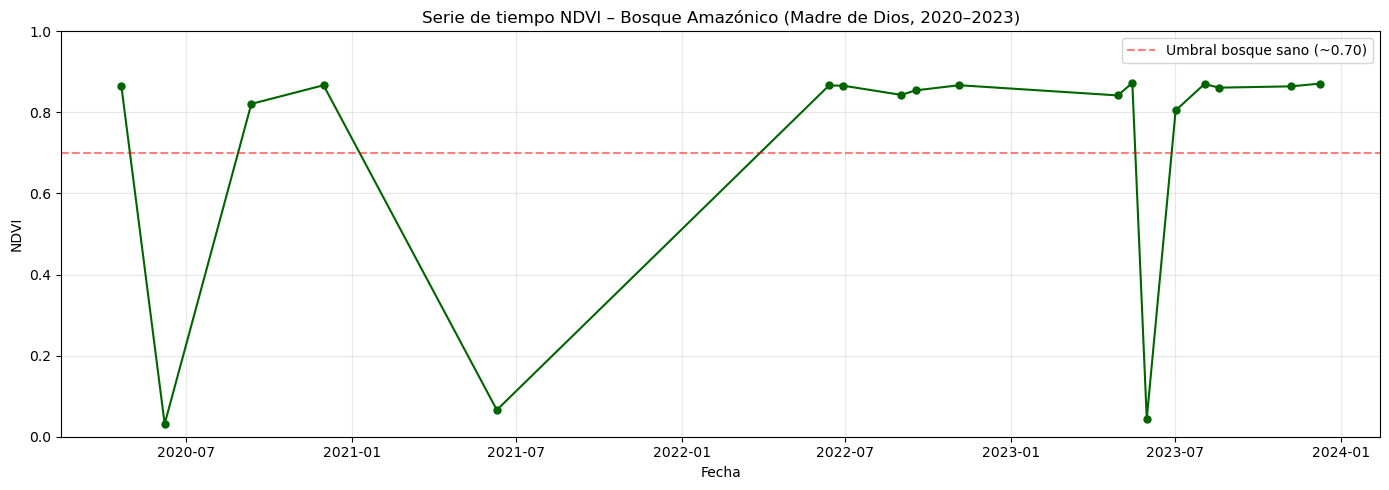

NDVI promedio: 0.721
Los valores altos y consistentes indican bosque primario sano.


In [ ]:
# Graficar serie de tiempo de NDVI
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_ts['fecha'], df_ts['NDVI'], 'o-', color='darkgreen', linewidth=1.5, markersize=5)
ax.axhline(0.7, color='red', linestyle='--', alpha=0.5, label='Umbral bosque sano (~0.70)')

ax.set_xlabel('Fecha')
ax.set_ylabel('NDVI')
ax.set_title('Serie de tiempo NDVI – Bosque Amazónico (Madre de Dios, 2020–2023)')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print(f"NDVI promedio: {df_ts['NDVI'].mean():.3f}")
print(f"Los valores altos y consistentes indican bosque primario sano.")

In [ ]:
# Filtro de calidad: eliminar valores sospechosamente bajos para bosque primario
# (causados por humo, cirrus no detectado, o sombras residuales)
n_antes = len(df_ts)
df_ts = df_ts[df_ts['NDVI'] > 0.1]
n_eliminados = n_antes - len(df_ts)
if n_eliminados > 0:
    print(f"Advertencia: {n_eliminados} observaciones eliminadas por NDVI < 0.3")
    print("  Causa probable: humo de incendios, cirrus, o sombras residuales.")

print(f"Serie de tiempo: {len(df_ts)} obs. validas ({df_ts['fecha'].min().date()} - {df_ts['fecha'].max().date()})")
df_ts.head()

Advertencia: 3 observaciones eliminadas por NDVI < 0.3
  Causa probable: humo de incendios, cirrus, o sombras residuales.
Serie de tiempo: 15 obs. validas (2020-04-20 - 2023-12-09)


,NDVI,fecha
0,0.865539,2020-04-20
2,0.820949,2020-09-11
3,0.867013,2020-11-30
6,0.866457,2022-06-13
7,0.865847,2022-06-29


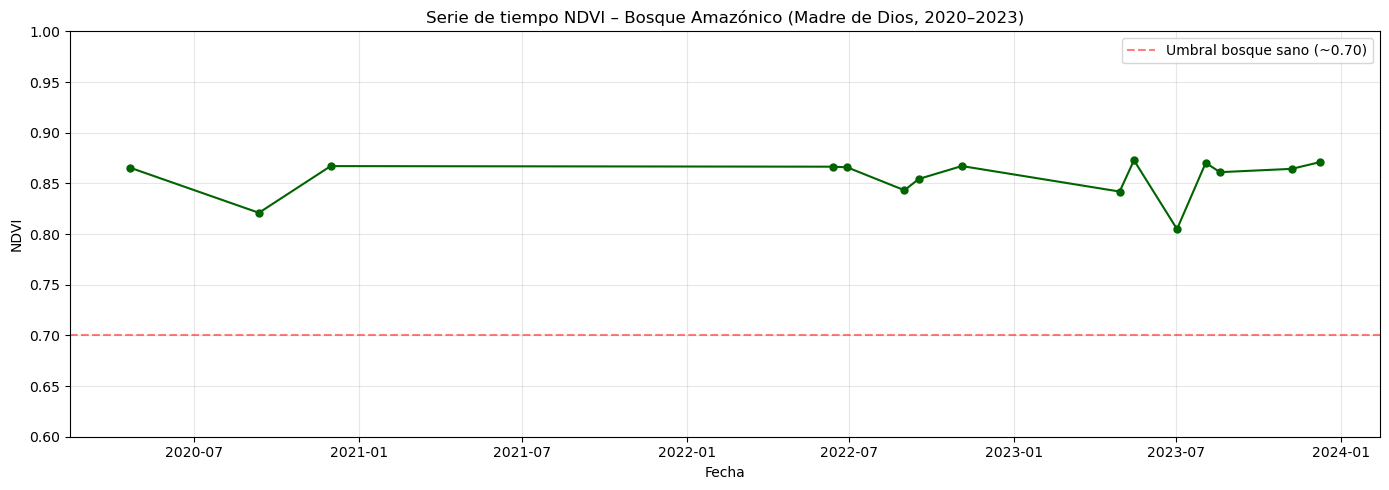

NDVI promedio: 0.856
Los valores altos y consistentes indican bosque primario sano.


In [ ]:
# Graficar serie de tiempo de NDVI
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_ts['fecha'], df_ts['NDVI'], 'o-', color='darkgreen', linewidth=1.5, markersize=5)
ax.axhline(0.7, color='red', linestyle='--', alpha=0.5, label='Umbral bosque sano (~0.70)')

ax.set_xlabel('Fecha')
ax.set_ylabel('NDVI')
ax.set_title('Serie de tiempo NDVI – Bosque Amazónico (Madre de Dios, 2020–2023)')
ax.set_ylim(0.6, 1)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print(f"NDVI promedio: {df_ts['NDVI'].mean():.3f}")
print(f"Los valores altos y consistentes indican bosque primario sano.")

---
## 8. Exportar Datos

Puedes exportar imágenes procesadas a Google Drive para análisis posteriores.

In [ ]:
# Exportar el composito NDVI de Madre de Dios
tarea_exportar = ee.batch.Export.image.toDrive(
    image=composito.select(['SR_B4', 'SR_B3', 'SR_B2', 'NDVI']),
    description='MadreDeDios_NDVI_2023',
    folder='GEE_Peru',
    region=lima_depto.geometry(),
    scale=30,
    crs='EPSG:4326',
    maxPixels=1e9
)

# Descomentar para ejecutar la exportación:
# tarea_exportar.start()
# print("Exportación iniciada! Revisa Google Drive en unos minutos.")

print("Tarea de exportación configurada (descomenta .start() para ejecutar)")

Tarea de exportación configurada (descomenta .start() para ejecutar)


In [ ]:
# Exportar una tabla (FeatureCollection) a Drive como CSV

export_table = ee.batch.Export.table.toDrive(
    collection=ndvi_por_depto,
    description='Peru_Dep_NDVI_Stats',
    folder='GEE_Exports',
    fileFormat='CSV'
)

# Descomentar para comenzar:
# export_table.start()

print("Exportación de tabla configurada")

Exportación de tabla configurada


---
## 🔬 Ejercicio Integrador

Analiza el impacto de los incendios forestales en la Amazonia peruana. Utiliza un buffer de 50 km a partir de Pucalpa (-74.5539, -8.3791).
En la región de Pucalpa ocurrieron diferentes incendios entre 18-07-2024 y 31-10-2024:
Mas info [aquí](https://un-spider.org/es/node/10959)

1. Filtra imágenes Landsat sobre la región de Pucalpa durante la época seca de 2024
2. Crea un composito mediano y calcula el NBR (Normalized Burn Ratio: `(NIR - SWIR2)/(NIR + SWIR2)`)
1. Generar el dNBR= NBRpre - NBRpost
3. Crea una máscara de áreas potencialmente quemadas: dNBR > -0.6
4. Calcula el área quemada dNBR > 0.6

In [ ]:
# ════════════════════════════════════════════════════════════════
#  EJERCICIO: Monitoreo de Incendios Forestales — Pucallpa 2024
# ════════════════════════════════════════════════════════════════
# Contexto: Durante el 2024 ocurrieron incendios forestales severos
# en la región de Ucayali, Perú, particularmente en los meses de
# agosto-octubre. Usaremos imágenes Sentinel-2 y el índice dNBR
# para estimar el área afectada alrededor de Pucallpa.
#
# Índice NBR (Normalized Burn Ratio):
#   NBR = (NIR - SWIR) / (NIR + SWIR)   →  bandas B8 y B12 en Sentinel-2
#
# Índice dNBR (diferencia NBR):
#   dNBR = NBR_pre-incendio − NBR_post-incendio
#   dNBR > 0  →  vegetación perdida (posible quema)
#   dNBR > 0.6 →  quema severa
# ════════════════════════════════════════════════════════════════

# ── 1. Área de interés: buffer alrededor de Pucallpa ─────────────
# Coordenadas de Pucallpa: longitud = -74.5539, latitud = -8.3791
# Crea un buffer de 50 km alrededor del centro de Pucallpa

pucallpa = ee.Geometry.Point(????)          # <-- completa las coordenadas
aoi      = pucallpa.buffer(????)            # <-- radio del buffer en metros


# ── 2. Fechas de interés ─────────────────────────────────────────
# Define las fechas de referencia pre y post incendio.
# Usa ventanas de 1 mes a partir de cada fecha.
#
# Pista: los incendios en Ucayali 2024 ocurrieron principalmente
#        entre agosto y octubre.

fecha_pre  = ee.Date('????-??-??')          # <-- antes del incendio
fecha_post = ee.Date('????-??-??')          # <-- después del incendio


# ── 3. Cargar Sentinel-2 y crear compositos ───────────────────────
s2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(aoi) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))

# Composito mediano en la ventana pre-incendio (1 mes desde fecha_pre)
pre_fuego  = (s2.filterDate(fecha_pre,  fecha_pre.advance(1, 'month'))
                .median().clip(aoi))

# Composito mediano en la ventana post-incendio (1 mes desde fecha_post)
post_fuego = (s2.filterDate(fecha_post, fecha_post.advance(1, 'month'))
                .median().clip(aoi))

print(f"Imágenes pre-fuego:  {s2.filterDate(fecha_pre, fecha_pre.advance(1,'month')).size().getInfo()}")
print(f"Imágenes post-fuego: {s2.filterDate(fecha_post, fecha_post.advance(1,'month')).size().getInfo()}")


# ── 4. Calcular NBR y dNBR ────────────────────────────────────────
# En Sentinel-2: NIR = B8, SWIR = B12

nbr_pre  = pre_fuego.normalizedDifference(['B8', 'B12']).rename('NBR_pre')
nbr_post = post_fuego.????.rename('NBR_post')             # <-- completa

# dNBR = NBR_pre - NBR_post
dnbr = ????.subtract(????).rename('dNBR')                 # <-- completa


# ── 5. Clasificar áreas quemadas ──────────────────────────────────
# Umbral: dNBR > 0.6 → quema severa
area_quemada = dnbr.gt(????)                              # <-- umbral


# ── 6. Calcular el área afectada en km² ──────────────────────────
area_px = area_quemada.multiply(ee.Image.pixelArea()) \
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=20,
        maxPixels=1e9
    )

area_km2 = ee.Number(area_px.get('dNBR')).divide(1e6)
print(f"Área quemada estimada: {area_km2.getInfo():.1f} km²")


# ── 7. Visualizar en el mapa ──────────────────────────────────────
vis_rgb = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000, 'gamma': 1.4}
vis_nbr = {'min': -1, 'max': 1,
           'palette': ['white', 'black', 'yellow', 'orange', 'red']}
vis_quemado = {'min': 0, 'max': 1, 'palette': ['white', 'red']}

Map = geemap.Map()
MapMap.centerObject(aoi, zoom=10)

Map.addLayer(pre_fuego,  vis_rgb,     'Pre-incendio (RGB)')
Map.addLayer(post_fuego, vis_rgb,     'Post-incendio (RGB)')
Map.addLayer(nbr_pre,    vis_quemado, 'NBR pre-incendio')
Map.addLayer(nbr_post,   vis_quemado, 'NBR post-incendio')
Map.addLayer(dnbr,       vis_nbr,     'dNBR')
Map.addLayer(area_quemada.selfMask(), vis_quemado, 'Area quemada (dNBR > 0.6)')

Map


---
## Resumen

### Conceptos clave

| Concepto | Descripción |
|----------|-------------|
| Firma espectral | Cada cobertura refleja la luz de manera diferente en cada banda |
| NDVI | (NIR - Rojo)/(NIR + Rojo); mide el verdor de la vegetación |
| NBR | (NIR - SWIR2)/(NIR + SWIR2); detecta áreas quemadas |
| Servidor vs. cliente | Los objetos `ee.` se procesan en los servidores de Google |
| Evaluación diferida | GEE no calcula hasta que llamas `.getInfo()` o visualizas |
| Composito mediano | Combina múltiples imágenes para reducir efecto de nubes |
| Enmascaramiento | Poner píxeles a transparente/nulo según un criterio |

### Tipos de datos GEE

| Tipo | Uso |
|------|-----|
| `ee.Geometry` | Definir ubicaciones y regiones (puntos, rectángulos, polígonos) |
| `ee.Feature` | Geometría con propiedades (nombre, área, etc.) |
| `ee.FeatureCollection` | Colección de features (departamentos, cuencas...) |
| `ee.Image` | Una imagen ráster (DEM, una escena Landsat) |
| `ee.ImageCollection` | Serie temporal de imágenes |

### Operaciones comunes

| Tarea | Código |
|-------|--------|
| Filtrar por fecha | `.filterDate('inicio', 'fin')` |
| Filtrar por ubicación | `.filterBounds(geometria)` |
| Filtrar FeatureCollection | `.filter(ee.Filter.eq('campo', valor))` |
| Aplicar función a toda la colección | `.map(funcion)` |
| Crear composito sin nubes | `.median()` |
| Calcular índice espectral | `.normalizedDifference(['B1', 'B2'])` |
| Crear máscara | `.gt(umbral)` luego `.updateMask(mascara)` |
| Estadísticas de una región | `.reduceRegion(reducer, geometria, escala)` |
| Estadísticas de múltiples regiones | `.reduceRegions(coleccion, reducer, escala)` |